# Changes to aridity classifications over the historical period

PET and aridity computed from `pm_pet.py` script

In [ ]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import cmocean.cm as cmo
import cartopy.crs as ccrs
import xclimate as xclim

In [27]:
def classify_aridity_index(ai: xr.DataArray) -> xr.DataArray:
    """
    Classify gridcells as {hyperarid, arid, semiarid, dry semiarid}.

    Aridity classifications:
    ------------------------
    hyperarid:            AI < 0.05
    arid:         0.05 <= AI < 0.20
    semiarid:     0.20 <= AI < 0.50
    dry semiarid: 0.50 <= AI < 0.65

    Indices:
    --------
    hyperarid:    0
    arid:         1
    semiarid:     2
    dry semiarid: 3
    """

    ARIDITY_CLASS_BOUNDS = [
        [-np.inf, 0.05],
        [0.05, 0.2],
        [0.2, 0.5],
        [0.5, 0.65],
    ]
    ARIDITY_CLASSES = ["hyperarid", "arid", "semiarid", "dry_subhumid"]

    ai_class_masks = []
    for lo, hi in ARIDITY_CLASS_BOUNDS:
        mask = (ai >= lo) & (ai < hi)
        ai_class_masks.append(mask)
    
    ai_class_masks = xr.concat(ai_class_masks, dim="class")
    ai_class_masks = ai_class_masks.assign_coords(
        {
            "class": np.arange(4),
            "class_name": ("class", ARIDITY_CLASSES)
        }
    )
    ai_class_masks.attrs = {
        "long_name": "aridity classifications",
        "description": (
            "hyperarid:  AI < 0.05\n"
            "arid:  0.05 <= AI < 0.20\n"
            "semiarid:  0.20 <= AI < 0.50\n"
            "dry semiarid  0.50 <= AI < 0.65"
        )
    }
    return ai_class_masks

In [5]:
fhist_grid = xclim.load_fhist_ppe_grid()
goga_grid = xclim.load_goga2_grid()
lens_grid = xclim.load_cesm2le_grid()

In [231]:
ROOTDIR = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/pet")
DEFAULT_ANALYSIS_CHUNKS = {
    "time": -1,
    "member": 1,
    "lat": 48,
    "lon": 96,
}
LATS = slice(-57, None)

## LENS2
lens_pet = xr.open_dataset(ROOTDIR / "LENS2.pm_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
lens_ai = xr.open_dataset(ROOTDIR / "LENS2.pm_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
lens_ai_class = xr.open_dataset(ROOTDIR / "LENS2.pm_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

lens_rad_pet = xr.open_dataset(ROOTDIR / "LENS2.rad_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
lens_rad_ai = xr.open_dataset(ROOTDIR / "LENS2.rad_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
lens_rad_ai_class = xr.open_dataset(ROOTDIR / "LENS2.rad_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

lens_pet = lens_pet.PET.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)
lens_ai = lens_ai.AI.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)
lens_ai_class = lens_ai_class.AI_CLASS.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)

lens_rad_pet = lens_rad_pet.PET.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)
lens_rad_ai = lens_rad_ai.AI.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)
lens_rad_ai_class = lens_rad_ai_class.AI_CLASS.reindex_like(lens_grid, method='nearest', tolerance=1e-3).where(lens_grid.LANDAREA > 0).sel(lat=LATS)

## GOGA2
goga_pet = xr.open_dataset(ROOTDIR / "GOGA2.pm_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
goga_ai = xr.open_dataset(ROOTDIR / "GOGA2.pm_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
goga_ai_class = xr.open_dataset(ROOTDIR / "GOGA2.pm_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

goga_rad_pet = xr.open_dataset(ROOTDIR / "GOGA2.rad_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
goga_rad_ai = xr.open_dataset(ROOTDIR / "GOGA2.rad_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
goga_rad_ai_class = xr.open_dataset(ROOTDIR / "GOGA2.rad_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

goga_pet = goga_pet.PET.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)
goga_ai = goga_ai.AI.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)
goga_ai_class = goga_ai_class.AI_CLASS.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)

goga_rad_pet = goga_rad_pet.PET.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)
goga_rad_ai = goga_rad_ai.AI.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)
goga_rad_ai_class = goga_rad_ai_class.AI_CLASS.reindex_like(goga_grid, method='nearest', tolerance=1e-3).where(goga_grid.LANDAREA > 0).sel(lat=LATS)

## FHIST
fhist_pet = xr.open_dataset(ROOTDIR / "FHIST.pm_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
fhist_ai = xr.open_dataset(ROOTDIR / "FHIST.pm_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
fhist_ai_class = xr.open_dataset(ROOTDIR / "FHIST.pm_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

fhist_rad_pet = xr.open_dataset(ROOTDIR / "FHIST.rad_pet.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
fhist_rad_ai = xr.open_dataset(ROOTDIR / "FHIST.rad_pet_ai.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)
fhist_rad_ai_class = xr.open_dataset(ROOTDIR / "FHIST.rad_pet_ai_class.annual_mean.195001-201412.nc", chunks=DEFAULT_ANALYSIS_CHUNKS)

fhist_pet = fhist_pet.PET.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)
fhist_ai = fhist_ai.AI.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)
fhist_ai_class = fhist_ai_class.AI_CLASS.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)

fhist_rad_pet = fhist_rad_pet.PET.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)
fhist_rad_ai = fhist_rad_ai.AI.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)
fhist_rad_ai_class = fhist_rad_ai_class.AI_CLASS.reindex_like(fhist_grid, method='nearest', tolerance=1e-3).where(fhist_grid.LANDAREA > 0).sel(lat=LATS)

In [232]:
YEARS = {
    "early": slice(1950, 1969),
    "late": slice(1995, 2014),
    "full": slice(1950, 2014),
}



lens_pet_tavg = {}
goga_pet_tavg = {}
fhist_pet_tavg = {}

lens_ai_tavg = {}
goga_ai_tavg = {}
fhist_ai_tavg = {}

lens_ai_class_tavg = {}
goga_ai_class_tavg = {}
fhist_ai_class_tavg = {}

lens_ai_class_la_tavg = {}
goga_ai_class_la_tavg = {}
fhist_ai_class_la_tavg = {}

lens_ai_class_lf_tavg = {}
goga_ai_class_lf_tavg = {}
fhist_ai_class_lf_tavg = {}

lens_ai_class_sum_tavg = {}
goga_ai_class_sum_tavg = {}
fhist_ai_class_sum_tavg = {}

lens_ai_class_frac_tavg = {}
goga_ai_class_frac_tavg = {}
fhist_ai_class_frac_tavg = {}

for name, yr in YEARS.items():
    lens_pet_tavg[name] = lens_pet.sel(year=yr).mean(dim='year').compute()
    goga_pet_tavg[name] = goga_pet.sel(year=yr).mean(dim='year').compute()
    fhist_pet_tavg[name] = fhist_pet.sel(year=yr).mean(dim='year').compute()

    lens_ai_tavg[name] = lens_ai.sel(year=yr).mean(dim='year').compute()
    goga_ai_tavg[name] = goga_ai.sel(year=yr).mean(dim='year').compute()
    fhist_ai_tavg[name] = fhist_ai.sel(year=yr).mean(dim='year').compute()

    lens_ai_class_tavg[name] = classify_aridity_index(lens_ai_tavg[name])
    goga_ai_class_tavg[name] = classify_aridity_index(goga_ai_tavg[name])
    fhist_ai_class_tavg[name] = classify_aridity_index(fhist_ai_tavg[name])
    
    lens_ai_class_la_tavg[name] = lens_ai_class_tavg[name] * lens_grid.LANDAREA.sel(lat=LATS)
    goga_ai_class_la_tavg[name] = goga_ai_class_tavg[name] * goga_grid.LANDAREA.sel(lat=LATS)
    fhist_ai_class_la_tavg[name] = fhist_ai_class_tavg[name] * fhist_grid.LANDAREA.sel(lat=LATS)

    lens_ai_class_lf_tavg[name] = lens_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / lens_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])
    goga_ai_class_lf_tavg[name] = goga_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / goga_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])
    fhist_ai_class_lf_tavg[name] = fhist_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / fhist_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])

    lens_ai_class_sum_tavg[name] = lens_ai_class_tavg[name].sum(dim='member')
    goga_ai_class_sum_tavg[name] = goga_ai_class_tavg[name].sum(dim='member')
    fhist_ai_class_sum_tavg[name] = fhist_ai_class_tavg[name].sum(dim='member')

    lens_ai_class_frac_tavg[name] = lens_ai_class_tavg[name].sum(dim='member') / len(lens_ai_class_tavg[name].member)
    goga_ai_class_frac_tavg[name] = goga_ai_class_tavg[name].sum(dim='member') / len(goga_ai_class_tavg[name].member)
    fhist_ai_class_frac_tavg[name] = fhist_ai_class_tavg[name].sum(dim='member') / len(fhist_ai_class_tavg[name].member)



lens_rad_pet_tavg = {}
goga_rad_pet_tavg = {}
fhist_rad_pet_tavg = {}

lens_rad_ai_tavg = {}
goga_rad_ai_tavg = {}
fhist_rad_ai_tavg = {}

lens_rad_ai_class_tavg = {}
goga_rad_ai_class_tavg = {}
fhist_rad_ai_class_tavg = {}

lens_rad_ai_class_la_tavg = {}
goga_rad_ai_class_la_tavg = {}
fhist_rad_ai_class_la_tavg = {}

lens_rad_ai_class_lf_tavg = {}
goga_rad_ai_class_lf_tavg = {}
fhist_rad_ai_class_lf_tavg = {}

lens_rad_ai_class_sum_tavg = {}
goga_rad_ai_class_sum_tavg = {}
fhist_rad_ai_class_sum_tavg = {}

lens_rad_ai_class_frac_tavg = {}
goga_rad_ai_class_frac_tavg = {}
fhist_rad_ai_class_frac_tavg = {}

for name, yr in YEARS.items():
    lens_rad_pet_tavg[name] = lens_rad_pet.sel(year=yr).mean(dim='year').compute()
    goga_rad_pet_tavg[name] = goga_rad_pet.sel(year=yr).mean(dim='year').compute()
    fhist_rad_pet_tavg[name] = fhist_rad_pet.sel(year=yr).mean(dim='year').compute()

    lens_rad_ai_tavg[name] = lens_rad_ai.sel(year=yr).mean(dim='year').compute()
    goga_rad_ai_tavg[name] = goga_rad_ai.sel(year=yr).mean(dim='year').compute()
    fhist_rad_ai_tavg[name] = fhist_rad_ai.sel(year=yr).mean(dim='year').compute()

    lens_rad_ai_class_tavg[name] = classify_aridity_index(lens_rad_ai_tavg[name])
    goga_rad_ai_class_tavg[name] = classify_aridity_index(goga_rad_ai_tavg[name])
    fhist_rad_ai_class_tavg[name] = classify_aridity_index(fhist_rad_ai_tavg[name])
    
    lens_rad_ai_class_la_tavg[name] = lens_rad_ai_class_tavg[name] * lens_grid.LANDAREA.sel(lat=LATS)
    goga_rad_ai_class_la_tavg[name] = goga_rad_ai_class_tavg[name] * goga_grid.LANDAREA.sel(lat=LATS)
    fhist_rad_ai_class_la_tavg[name] = fhist_rad_ai_class_tavg[name] * fhist_grid.LANDAREA.sel(lat=LATS)

    lens_rad_ai_class_lf_tavg[name] = lens_rad_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / lens_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])
    goga_rad_ai_class_lf_tavg[name] = goga_rad_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / goga_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])
    fhist_rad_ai_class_lf_tavg[name] = fhist_rad_ai_class_la_tavg[name].sum(dim=['lat', 'lon']) / fhist_grid.LANDAREA.sel(lat=LATS).sum(dim=['lat', 'lon'])

    lens_rad_ai_class_sum_tavg[name] = lens_rad_ai_class_tavg[name].sum(dim='member')
    goga_rad_ai_class_sum_tavg[name] = goga_rad_ai_class_tavg[name].sum(dim='member')
    fhist_rad_ai_class_sum_tavg[name] = fhist_rad_ai_class_tavg[name].sum(dim='member')

    lens_rad_ai_class_frac_tavg[name] = lens_rad_ai_class_tavg[name].sum(dim='member') / len(lens_rad_ai_class_tavg[name].member)
    goga_rad_ai_class_frac_tavg[name] = goga_rad_ai_class_tavg[name].sum(dim='member') / len(goga_rad_ai_class_tavg[name].member)
    fhist_rad_ai_class_frac_tavg[name] = fhist_rad_ai_class_tavg[name].sum(dim='member') / len(fhist_rad_ai_class_tavg[name].member)

Text(0.5, 0.98, 'Aridity Index using Penman-Monteith PET')

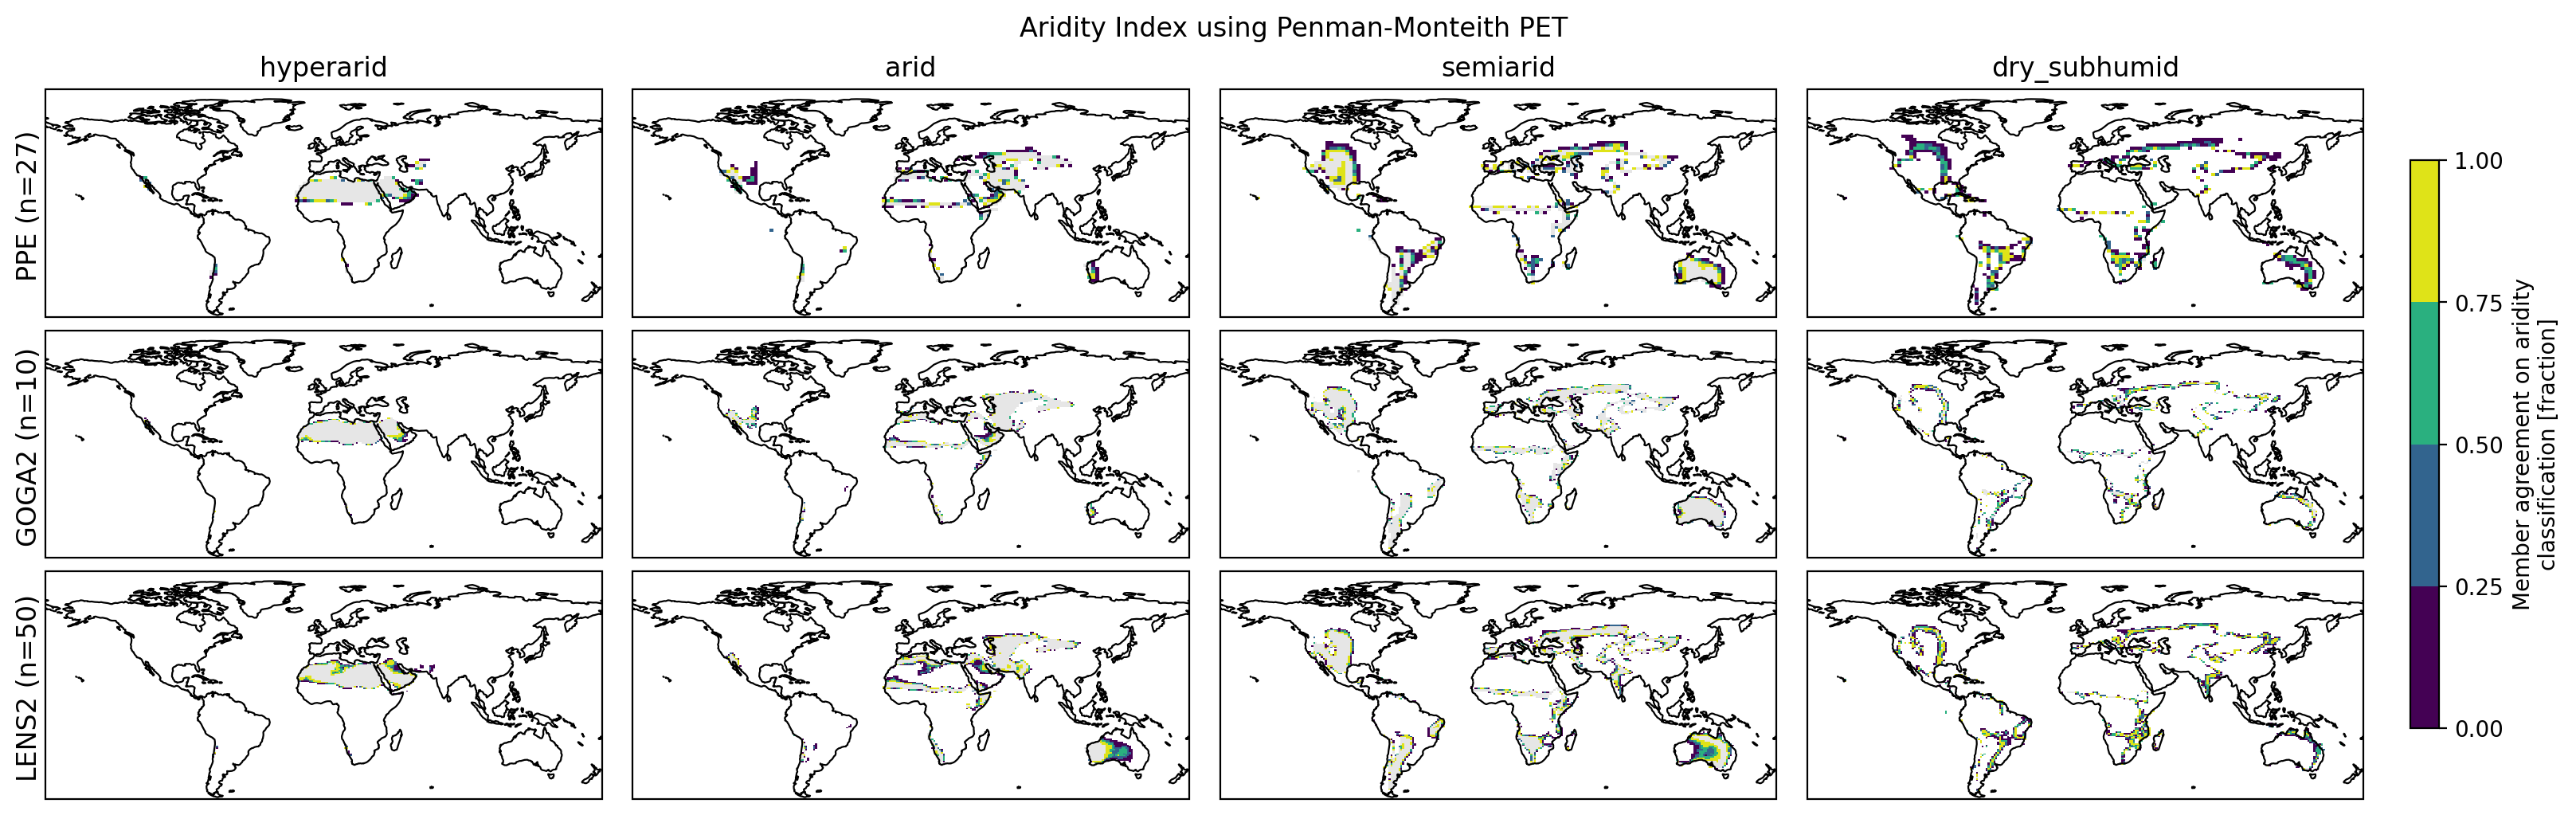

In [233]:
fig, axes = plt.subplots(
    3, 4,
    figsize=(16, 5),
    layout='constrained',
    sharex=True, sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=200
)
axs = axes.ravel()

levels = [0, 0.25, 0.5, 0.75, 1]
cmap_full = plt.get_cmap('viridis')
cmap = LinearSegmentedColormap.from_list(
    'cmap_clipped', cmap_full(np.linspace(0, 0.95, 256))
)
cmap = ListedColormap(cmap(np.linspace(0, 1, len(levels) - 1)))
norm = BoundaryNorm(levels, ncolors=cmap.N)

gray_cmap = ListedColormap(['0.9'])

for i in range(4):
    _fhist = fhist_ai_class_frac_tavg['late'].sel({'class': i}).where(fhist_grid.LANDAREA > 0)
    _fhist_full = _fhist.where(_fhist == 1)
    _fhist = _fhist.where((_fhist < 1) & (_fhist > 0))

    _goga = goga_ai_class_frac_tavg['late'].sel({'class': i}).where(goga_grid.LANDAREA > 0)
    _goga_full = _goga.where(_goga == 1)
    _goga = _goga.where((_goga < 1) & (_goga > 0))

    _lens = lens_ai_class_frac_tavg['late'].sel({'class': i}).where(lens_grid.LANDAREA > 0)
    _lens_full = _lens.where(_lens == 1)
    _lens = _lens.where((_lens < 1) & (_lens > 0))

    im = _fhist.plot(ax=axs[i], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _fhist_full.plot(ax=axs[i], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    _goga.plot(ax=axs[i+4], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _goga_full.plot(ax=axs[i+4], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    _lens.plot(ax=axs[i+8], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _lens_full.plot(ax=axs[i+8], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    axs[i].set_title(fhist_ai_class_frac_tavg['late'].sel({'class': i}).class_name.values)

for ax in axs:
    ax.coastlines(lw=0.8, color='k')

axs[0].text(x=-190, y=15, s='PPE (n=27)', rotation=90, ha='center', va='center', fontsize=12)
axs[4].text(x=-190, y=15, s='GOGA2 (n=10)', rotation=90, ha='center', va='center', fontsize=12)
axs[8].text(x=-190, y=15, s='LENS2 (n=50)', rotation=90, ha='center', va='center', fontsize=12)

fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Member agreement on aridity\nclassification [fraction]')
fig.suptitle('Aridity Index using Penman-Monteith PET')

Text(0.5, 0.98, 'Aridity Index using Penman-Monteith PET')

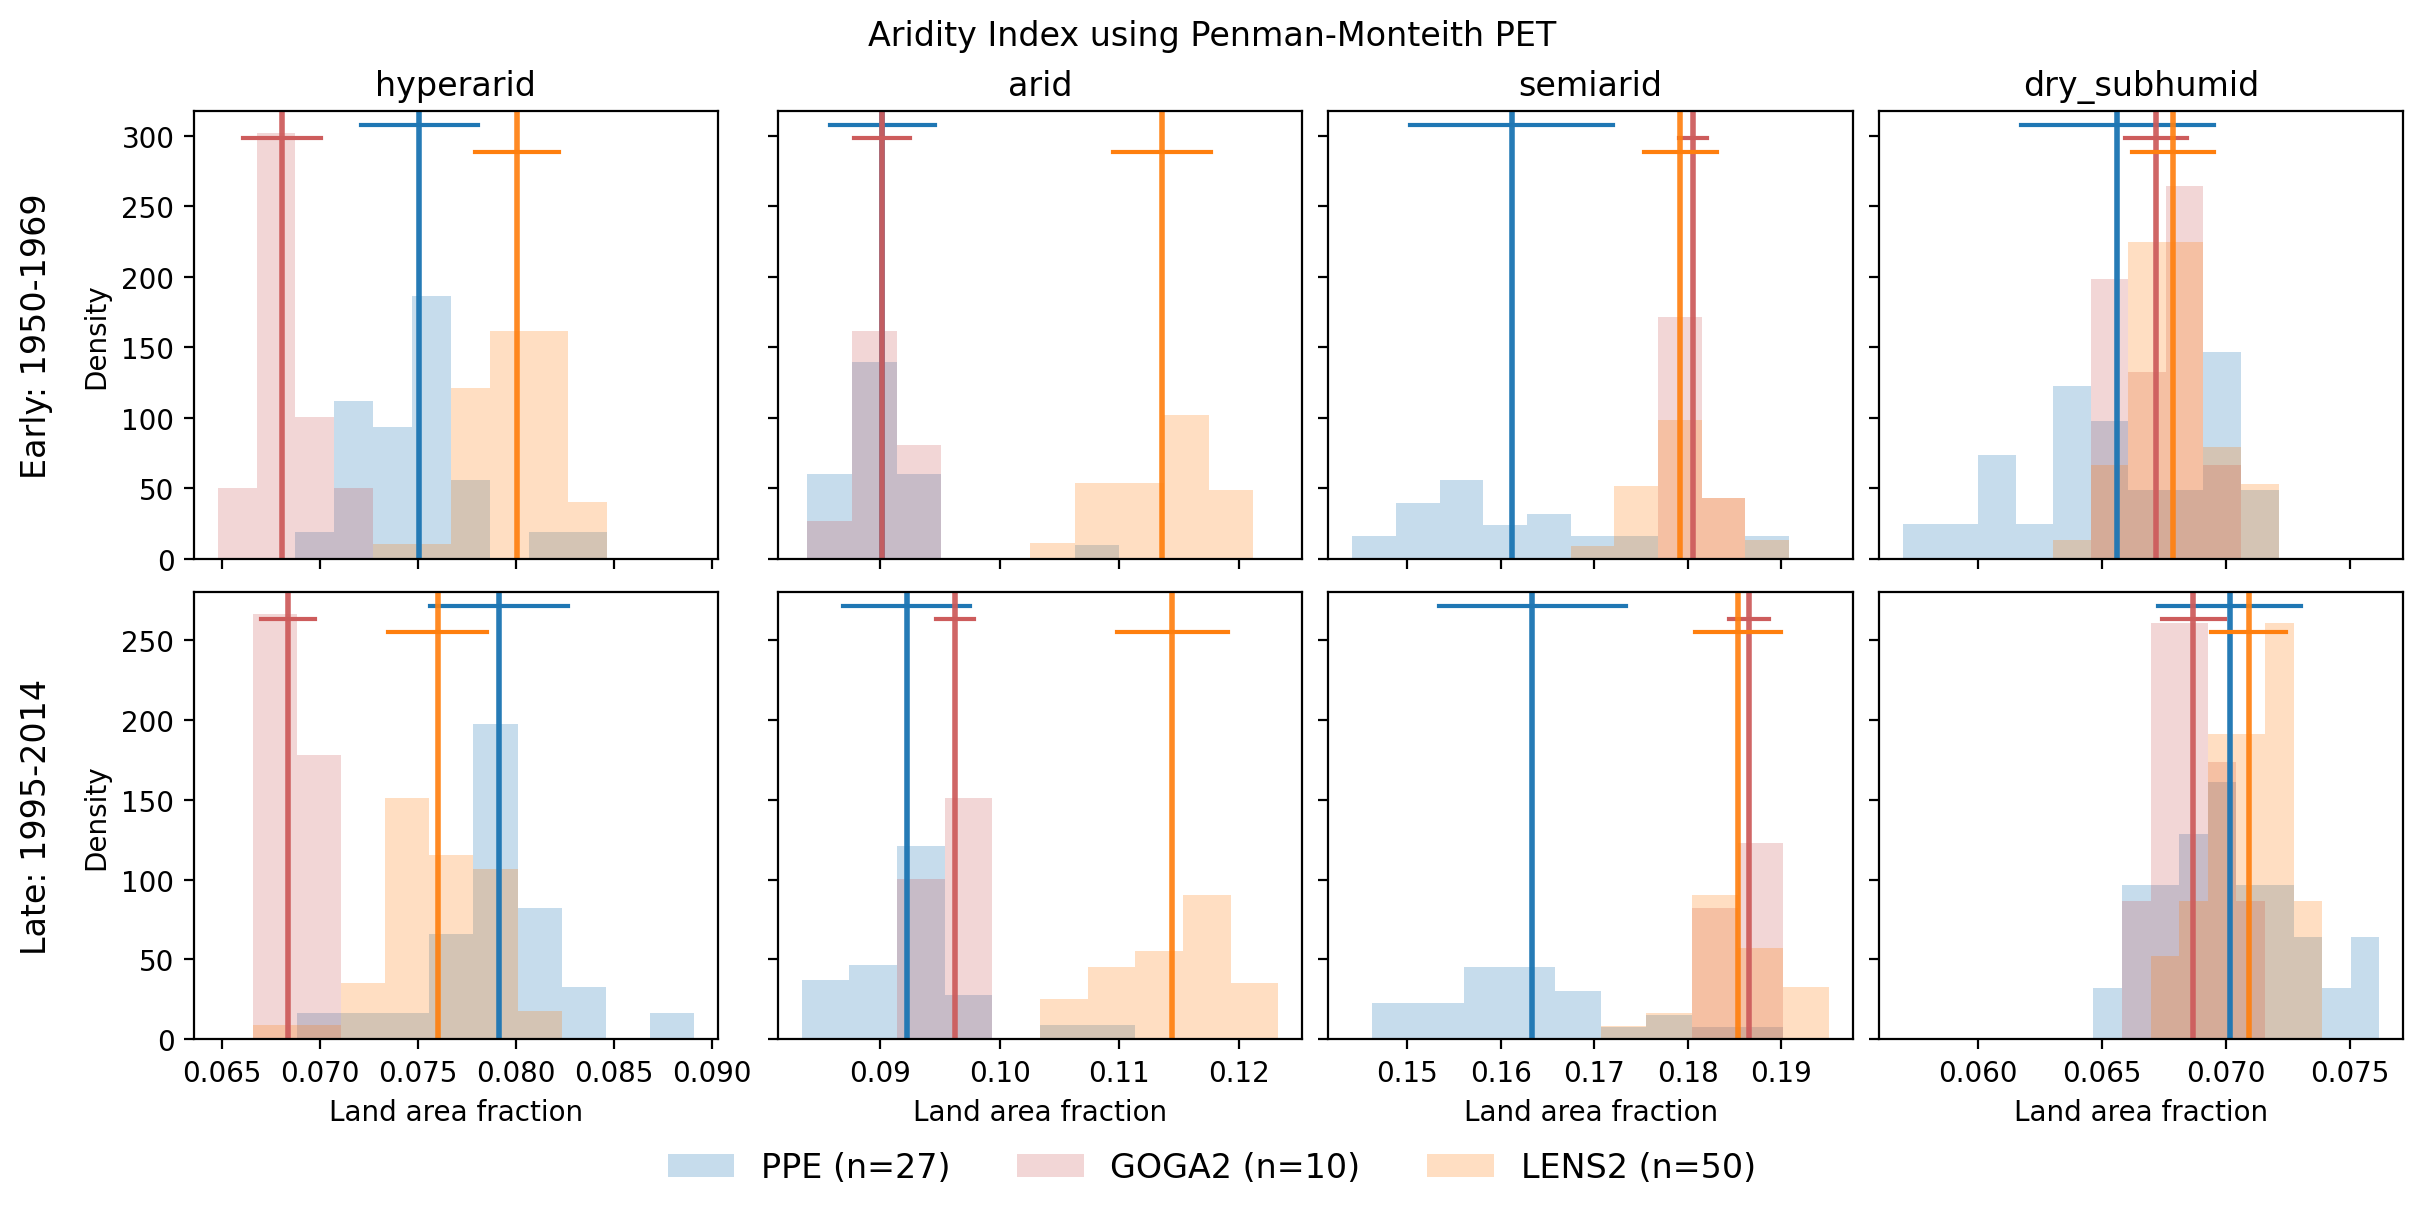

In [235]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6),
    layout='constrained',
    sharex='col',
    sharey='row',
    dpi=200
)
axs = axes.ravel()

ds_format = {
    'PPE': ('tab:blue', 0.97),
    'GOGA2': ('indianred', 0.94),
    'LENS2': ('tab:orange', 0.91),
}

for i in range(4):
    for j, yr in enumerate(['early', 'late']):
        _fhist = fhist_ai_class_lf_tavg[yr].sel({'class': i})
        _goga = goga_ai_class_lf_tavg[yr].sel({'class': i})
        _lens = lens_ai_class_lf_tavg[yr].sel({'class': i})

        combined = np.concatenate([
            _fhist.values.ravel(),
            _goga.values.ravel(),
            _lens.values.ravel(),
        ])
        combined = combined[~np.isnan(combined)]
        bin_edges = np.histogram_bin_edges(combined, bins=10)

        _fhist.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['PPE'], alpha=0.25, label="PPE (n=27)")
        _goga.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['GOGA2'], alpha=0.25, label="GOGA2 (n=10)")
        _lens.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['LENS2'], alpha=0.25, label="LENS2 (n=50)")

        for da, (label, (color, y_pos)) in zip([_fhist, _goga, _lens], ds_format.items()):
            axes[j, i].axvline(da.mean(dim='member'), color=ds_format[label], lw=2)

            m = float(da.mean(dim='member'))
            s = float(da.std(dim='member'))
            axes[j, i].plot(
                [m - s, m + s], [y_pos, y_pos],
                transform=axes[j, i].get_xaxis_transform(),
                color=color, lw=1.5,
                # solid_capstyle='butt',
                # marker='|', markersize=6,
            )

        axes[j, i].set_title('')
        axes[j, i].set_xlabel('')

for i in range(4):
    axs[i].set_title(fhist_ai_class_frac_tavg[yr].sel({'class': i}).class_name.values)

for ax in axs[4:]:
    ax.set_xlabel('Land area fraction')

axs[0].set_ylabel("Density")
axs[4].set_ylabel("Density")

axs[0].text(x=-0.3, y=0.5, s="Early: 1950-1969", fontsize=12, transform=axs[0].transAxes, rotation=90, ha='center', va='center')
axs[4].text(x=-0.3, y=0.5, s="Late: 1995-2014", fontsize=12, transform=axs[4].transAxes, rotation=90, ha='center', va='center')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', frameon=False, ncol=3, fontsize=12)

fig.suptitle('Aridity Index using Penman-Monteith PET')

Text(0.5, 0.98, 'Aridity Index using energy-only PET')

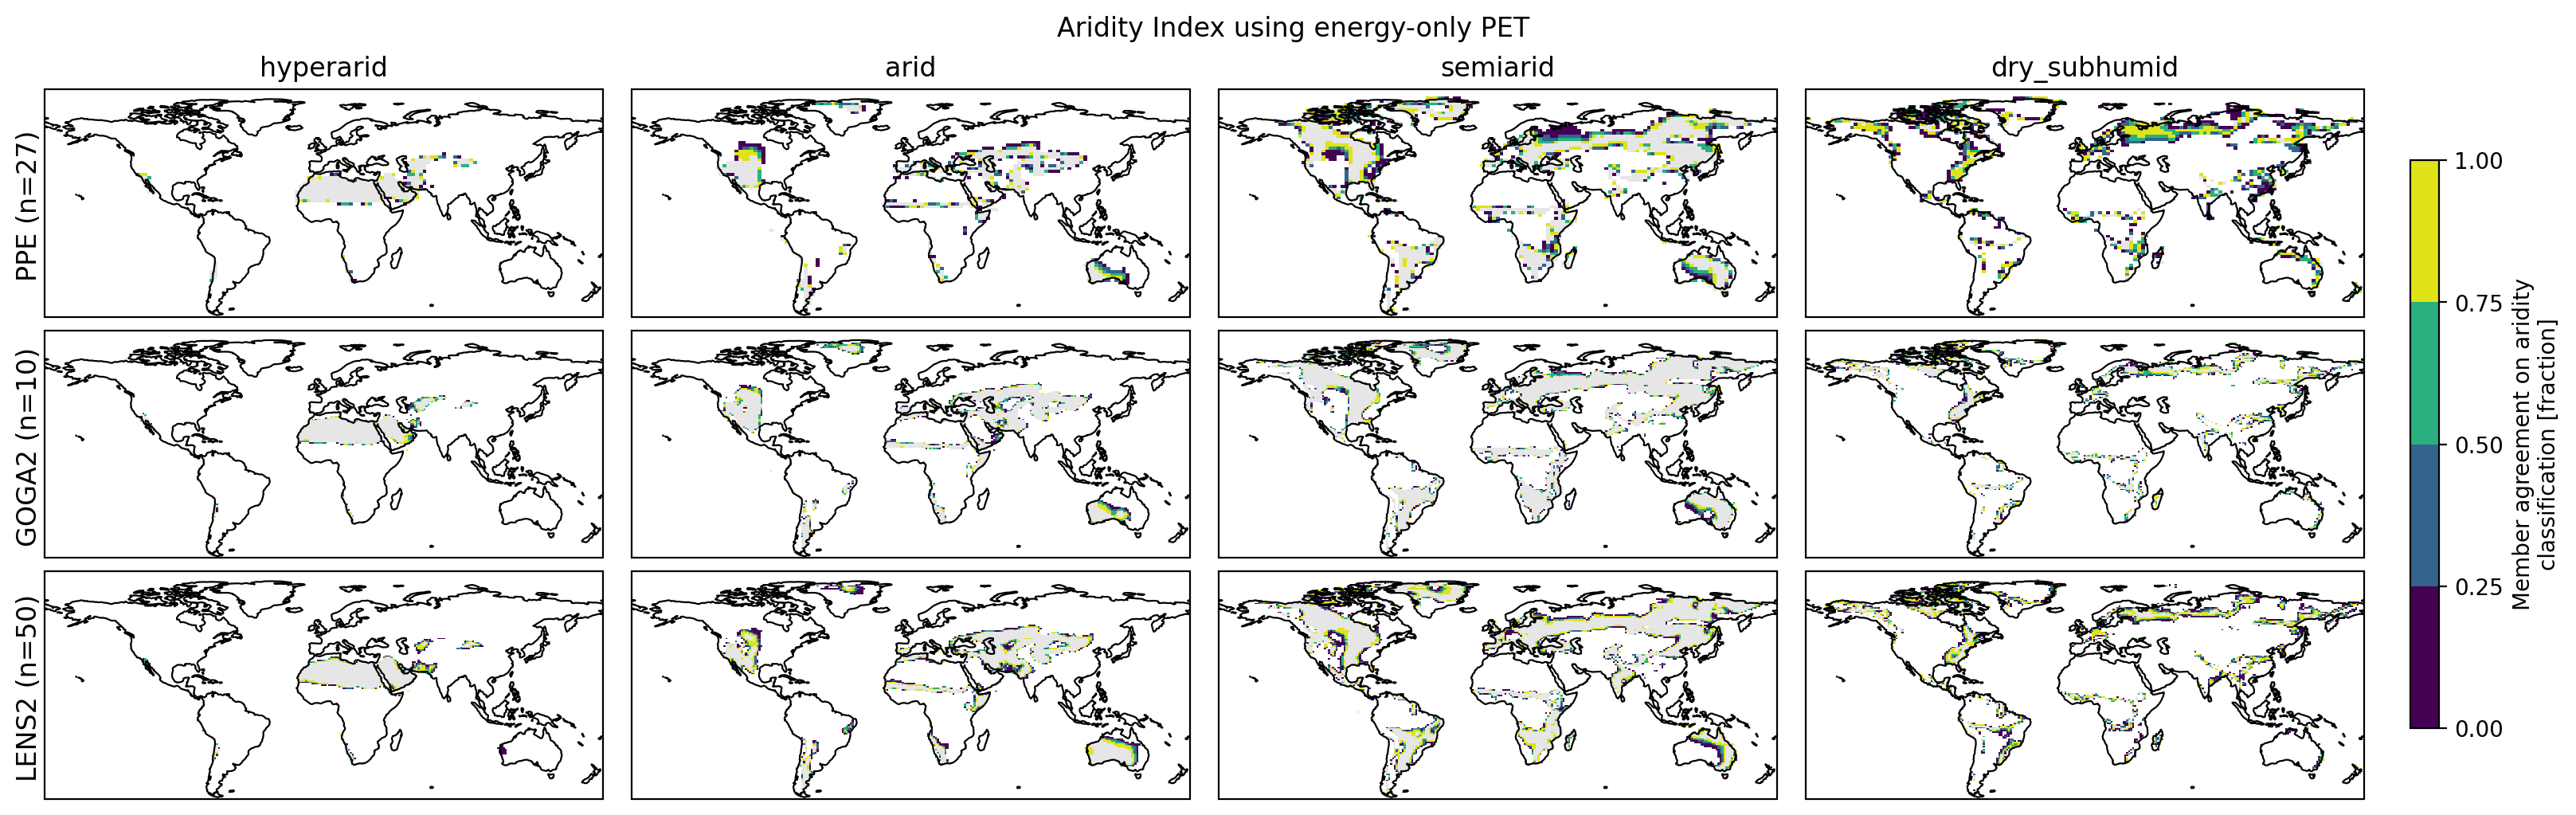

In [ ]:
fig, axes = plt.subplots(
    3, 4,
    figsize=(16, 5),
    layout='constrained',
    sharex=True, sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=200
)
axs = axes.ravel()

levels = [0, 0.25, 0.5, 0.75, 1]
cmap_full = plt.get_cmap('viridis')
cmap = LinearSegmentedColormap.from_list(
    'cmap_clipped', cmap_full(np.linspace(0, 0.95, 256))
)
cmap = ListedColormap(cmap(np.linspace(0, 1, len(levels) - 1)))
norm = BoundaryNorm(levels, ncolors=cmap.N)

gray_cmap = ListedColormap(['0.9'])

for i in range(4):
    _fhist = fhist_rad_ai_class_frac_tavg['late'].sel({'class': i}).where(fhist_grid.LANDAREA > 0)
    _fhist_full = _fhist.where(_fhist == 1)
    _fhist = _fhist.where((_fhist < 1) & (_fhist > 0))

    _goga = goga_rad_ai_class_frac_tavg['late'].sel({'class': i}).where(goga_grid.LANDAREA > 0)
    _goga_full = _goga.where(_goga == 1)
    _goga = _goga.where((_goga < 1) & (_goga > 0))

    _lens = lens_rad_ai_class_frac_tavg['late'].sel({'class': i}).where(lens_grid.LANDAREA > 0)
    _lens_full = _lens.where(_lens == 1)
    _lens = _lens.where((_lens < 1) & (_lens > 0))

    im = _fhist.plot(ax=axs[i], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _fhist_full.plot(ax=axs[i], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    _goga.plot(ax=axs[i+4], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _goga_full.plot(ax=axs[i+4], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    _lens.plot(ax=axs[i+8], cmap=cmap, norm=norm, vmin=0, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())
    _lens_full.plot(ax=axs[i+8], cmap=gray_cmap, vmin=1, vmax=1, add_colorbar=False, add_labels=False, transform=ccrs.PlateCarree())

    axs[i].set_title(fhist_rad_ai_class_frac_tavg['late'].sel({'class': i}).class_name.values)

for ax in axs:
    ax.coastlines(lw=0.8, color='k')

axs[0].text(x=-190, y=15, s='PPE (n=27)', rotation=90, ha='center', va='center', fontsize=12)
axs[4].text(x=-190, y=15, s='GOGA2 (n=10)', rotation=90, ha='center', va='center', fontsize=12)
axs[8].text(x=-190, y=15, s='LENS2 (n=50)', rotation=90, ha='center', va='center', fontsize=12)

fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02, label='Member agreement on aridity\nclassification [fraction]')
fig.suptitle('Aridity Index using energy-only PET')

Text(0.5, 0.98, 'Aridity Index using energy-only PET')

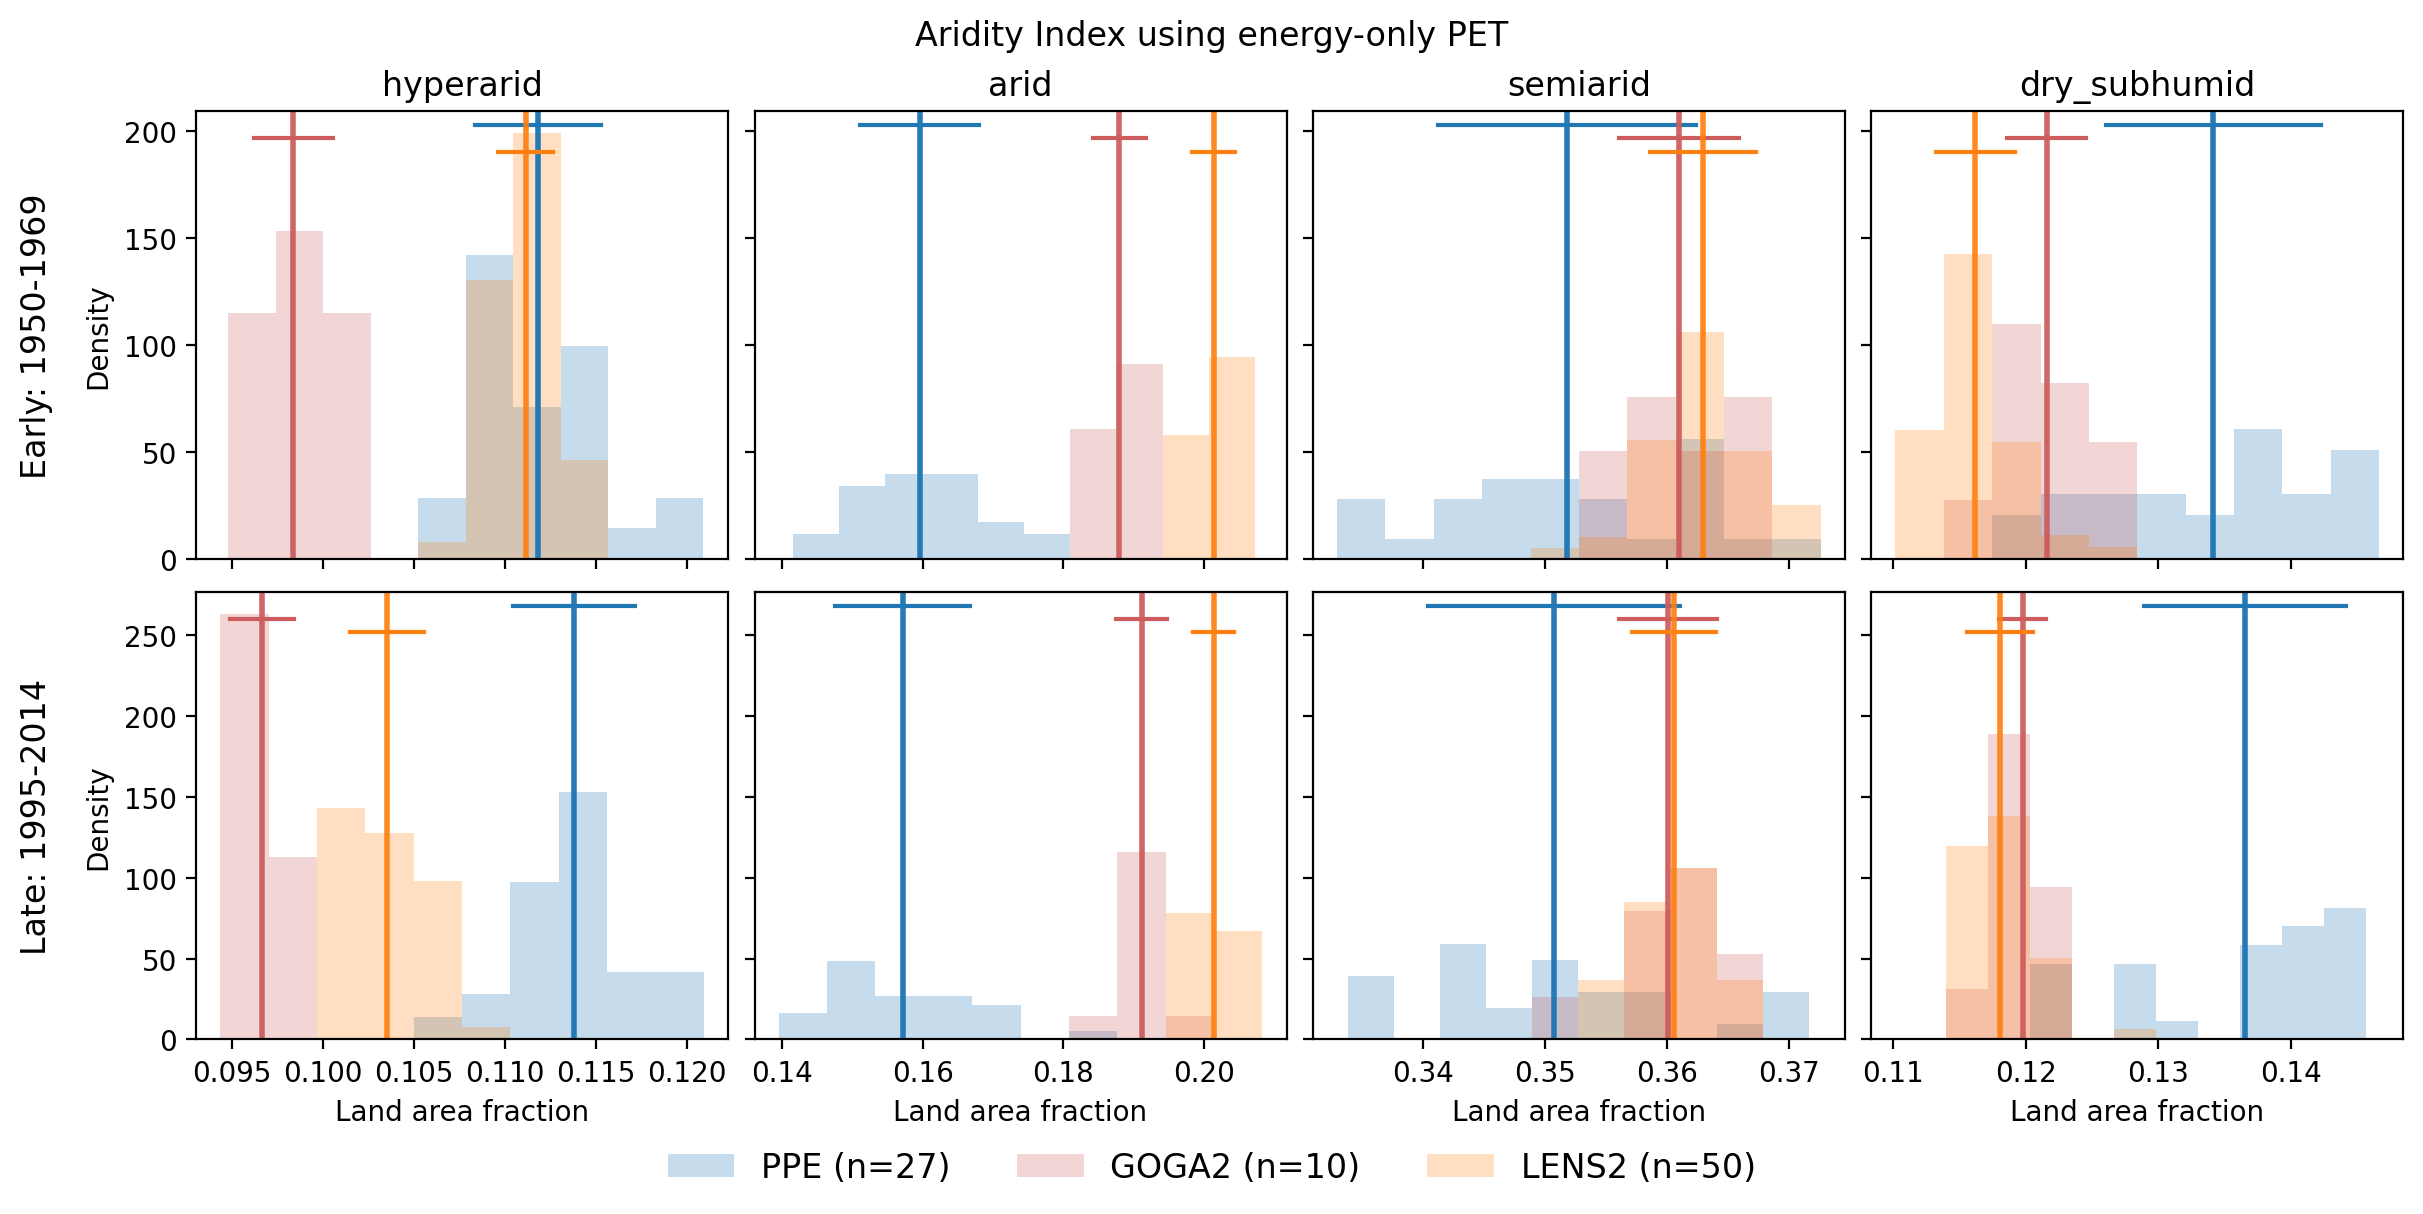

In [237]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6),
    layout='constrained',
    sharex='col',
    sharey='row',
    dpi=200
)
axs = axes.ravel()

ds_format = {
    'PPE': ('tab:blue', 0.97),
    'GOGA2': ('indianred', 0.94),
    'LENS2': ('tab:orange', 0.91),
}

for i in range(4):
    for j, yr in enumerate(['early', 'late']):
        _fhist = fhist_rad_ai_class_lf_tavg[yr].sel({'class': i})
        _goga = goga_rad_ai_class_lf_tavg[yr].sel({'class': i})
        _lens = lens_rad_ai_class_lf_tavg[yr].sel({'class': i})

        combined = np.concatenate([
            _fhist.values.ravel(),
            _goga.values.ravel(),
            _lens.values.ravel(),
        ])
        combined = combined[~np.isnan(combined)]
        bin_edges = np.histogram_bin_edges(combined, bins=10)

        _fhist.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['PPE'], alpha=0.25, label="PPE (n=27)")
        _goga.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['GOGA2'], alpha=0.25, label="GOGA2 (n=10)")
        _lens.plot.hist(ax=axes[j, i], bins=bin_edges, density=True, facecolor=ds_format['LENS2'], alpha=0.25, label="LENS2 (n=50)")

        for da, (label, (color, y_pos)) in zip([_fhist, _goga, _lens], ds_format.items()):
            axes[j, i].axvline(da.mean(dim='member'), color=ds_format[label], lw=2)

            m = float(da.mean(dim='member'))
            s = float(da.std(dim='member'))
            axes[j, i].plot(
                [m - s, m + s], [y_pos, y_pos],
                transform=axes[j, i].get_xaxis_transform(),
                color=color, lw=1.5,
                # solid_capstyle='butt',
                # marker='|', markersize=6,
            )

        axes[j, i].set_title('')
        axes[j, i].set_xlabel('')

for i in range(4):
    axs[i].set_title(fhist_ai_class_frac_tavg[yr].sel({'class': i}).class_name.values)

for ax in axs[4:]:
    ax.set_xlabel('Land area fraction')

axs[0].set_ylabel("Density")
axs[4].set_ylabel("Density")

axs[0].text(x=-0.3, y=0.5, s="Early: 1950-1969", fontsize=12, transform=axs[0].transAxes, rotation=90, ha='center', va='center')
axs[4].text(x=-0.3, y=0.5, s="Late: 1995-2014", fontsize=12, transform=axs[4].transAxes, rotation=90, ha='center', va='center')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', frameon=False, ncol=3, fontsize=12)

fig.suptitle('Aridity Index using energy-only PET')